## 1. Importacion de librerías y carga de dataset

In [38]:
%pip install pandas numpy seaborn matplotlib scikit-learn xgboost lightgbm tensorflow optuna -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf

import optuna

In [40]:
ruta_local = 'data/cleaned_diabetes_data_extended_v2.csv'  # O usa la ruta completa, por ejemplo: 'C:/ProyectosML/202502 - ML/TFM/diabetes_dataset.csv'
df = pd.read_csv(ruta_local)

#url = 'https://raw.githubusercontent.com/antitesis/datasets_academicos/refs/heads/main/diabetes_dataset.csv'
#df = pd.read_csv(url)

## 2. Analisis exploratorio

### 2.1. Descripción del dataset

In [41]:
print("Primeras filas del DataFrame:")
df.head()

Primeras filas del DataFrame:


,presion_alta,colesterol_alto,bmi,fumo_100_cigs,historial_acv,historial_cardiaco,actividad_fisica,salud_general,dias_mala_salud_fisica,dias_mala_salud_mental,...,sexo,grupo_edad,nivel_educativo,grupo_racial,actividad_300_min,actividad_muscular,diabetes_bin,frecuencia_frutas,frecuencia_verduras,ingresos_grupo
0,0,1,40.18,1,0,0,0,5,15,18,...,0,9,4,1,0,0,0,3,1,1
1,1,0,25.09,1,0,0,1,3,0,0,...,0,7,6,1,0,0,0,3,4,1
2,0,1,28.19,0,0,0,0,5,30,30,...,0,9,4,1,0,0,0,1,3,3
3,1,0,24.37,0,0,0,0,5,20,0,...,0,9,5,1,0,0,0,1,2,3
4,0,0,26.52,0,0,0,1,2,0,0,...,0,11,3,1,1,0,0,1,1,3


In [42]:
print("\nInformación del DataFrame:")
df.info()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358092 entries, 0 to 358091
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   presion_alta            358092 non-null  int64  
 1   colesterol_alto         358092 non-null  int64  
 2   bmi                     358092 non-null  float64
 3   fumo_100_cigs           358092 non-null  int64  
 4   historial_acv           358092 non-null  int64  
 5   historial_cardiaco      358092 non-null  int64  
 6   actividad_fisica        358092 non-null  int64  
 7   salud_general           358092 non-null  int64  
 8   dias_mala_salud_fisica  358092 non-null  int64  
 9   dias_mala_salud_mental  358092 non-null  int64  
 10  dificultad_caminar      358092 non-null  int64  
 11  sexo                    358092 non-null  int64  
 12  grupo_edad              358092 non-null  int64  
 13  nivel_educativo         358092 non-null  int64

In [43]:
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
        presion_alta  colesterol_alto            bmi  fumo_100_cigs  \
count  358092.000000    358092.000000  358092.000000  358092.000000   
mean        0.591934         0.373301      28.113720       0.438957   
std         0.491476         0.483682       6.667924       0.496260   
min         0.000000         0.000000      12.020000       0.000000   
25%         0.000000         0.000000      23.780000       0.000000   
50%         1.000000         0.000000      27.070000       0.000000   
75%         1.000000         1.000000      31.010000       1.000000   
max         1.000000         1.000000      97.650000       1.000000   

       historial_acv  historial_cardiaco  actividad_fisica  salud_general  \
count  358092.000000       358092.000000     358092.000000  358092.000000   
mean        0.041361            0.059686          0.725272       2.553165   
std         0.199124            0.236904          0.446378       1.082636   
min         0.000000    

In [44]:
print("\nValores únicos por columna:")
print(df.nunique())


Valores únicos por columna:
presion_alta                 2
colesterol_alto              2
bmi                       3636
fumo_100_cigs                2
historial_acv                2
historial_cardiaco           2
actividad_fisica             2
salud_general                5
dias_mala_salud_fisica      31
dias_mala_salud_mental      31
dificultad_caminar           2
sexo                         2
grupo_edad                  13
nivel_educativo              6
grupo_racial                 6
actividad_300_min              2
actividad_muscular           2
diabetes_bin                 2
frecuencia_frutas            4
frecuencia_verduras          4
ingresos_grupo               3
dtype: int64


### 2.2. Factores frecuentes de corrección

In [45]:
print("Numero de valores nulos por columna: ")
print(df.isnull().sum())

Numero de valores nulos por columna: 
presion_alta              0
colesterol_alto           0
bmi                       0
fumo_100_cigs             0
historial_acv             0
historial_cardiaco        0
actividad_fisica          0
salud_general             0
dias_mala_salud_fisica    0
dias_mala_salud_mental    0
dificultad_caminar        0
sexo                      0
grupo_edad                0
nivel_educativo           0
grupo_racial              0
actividad_300_min           0
actividad_muscular        0
diabetes_bin              0
frecuencia_frutas         0
frecuencia_verduras       0
ingresos_grupo            0
dtype: int64


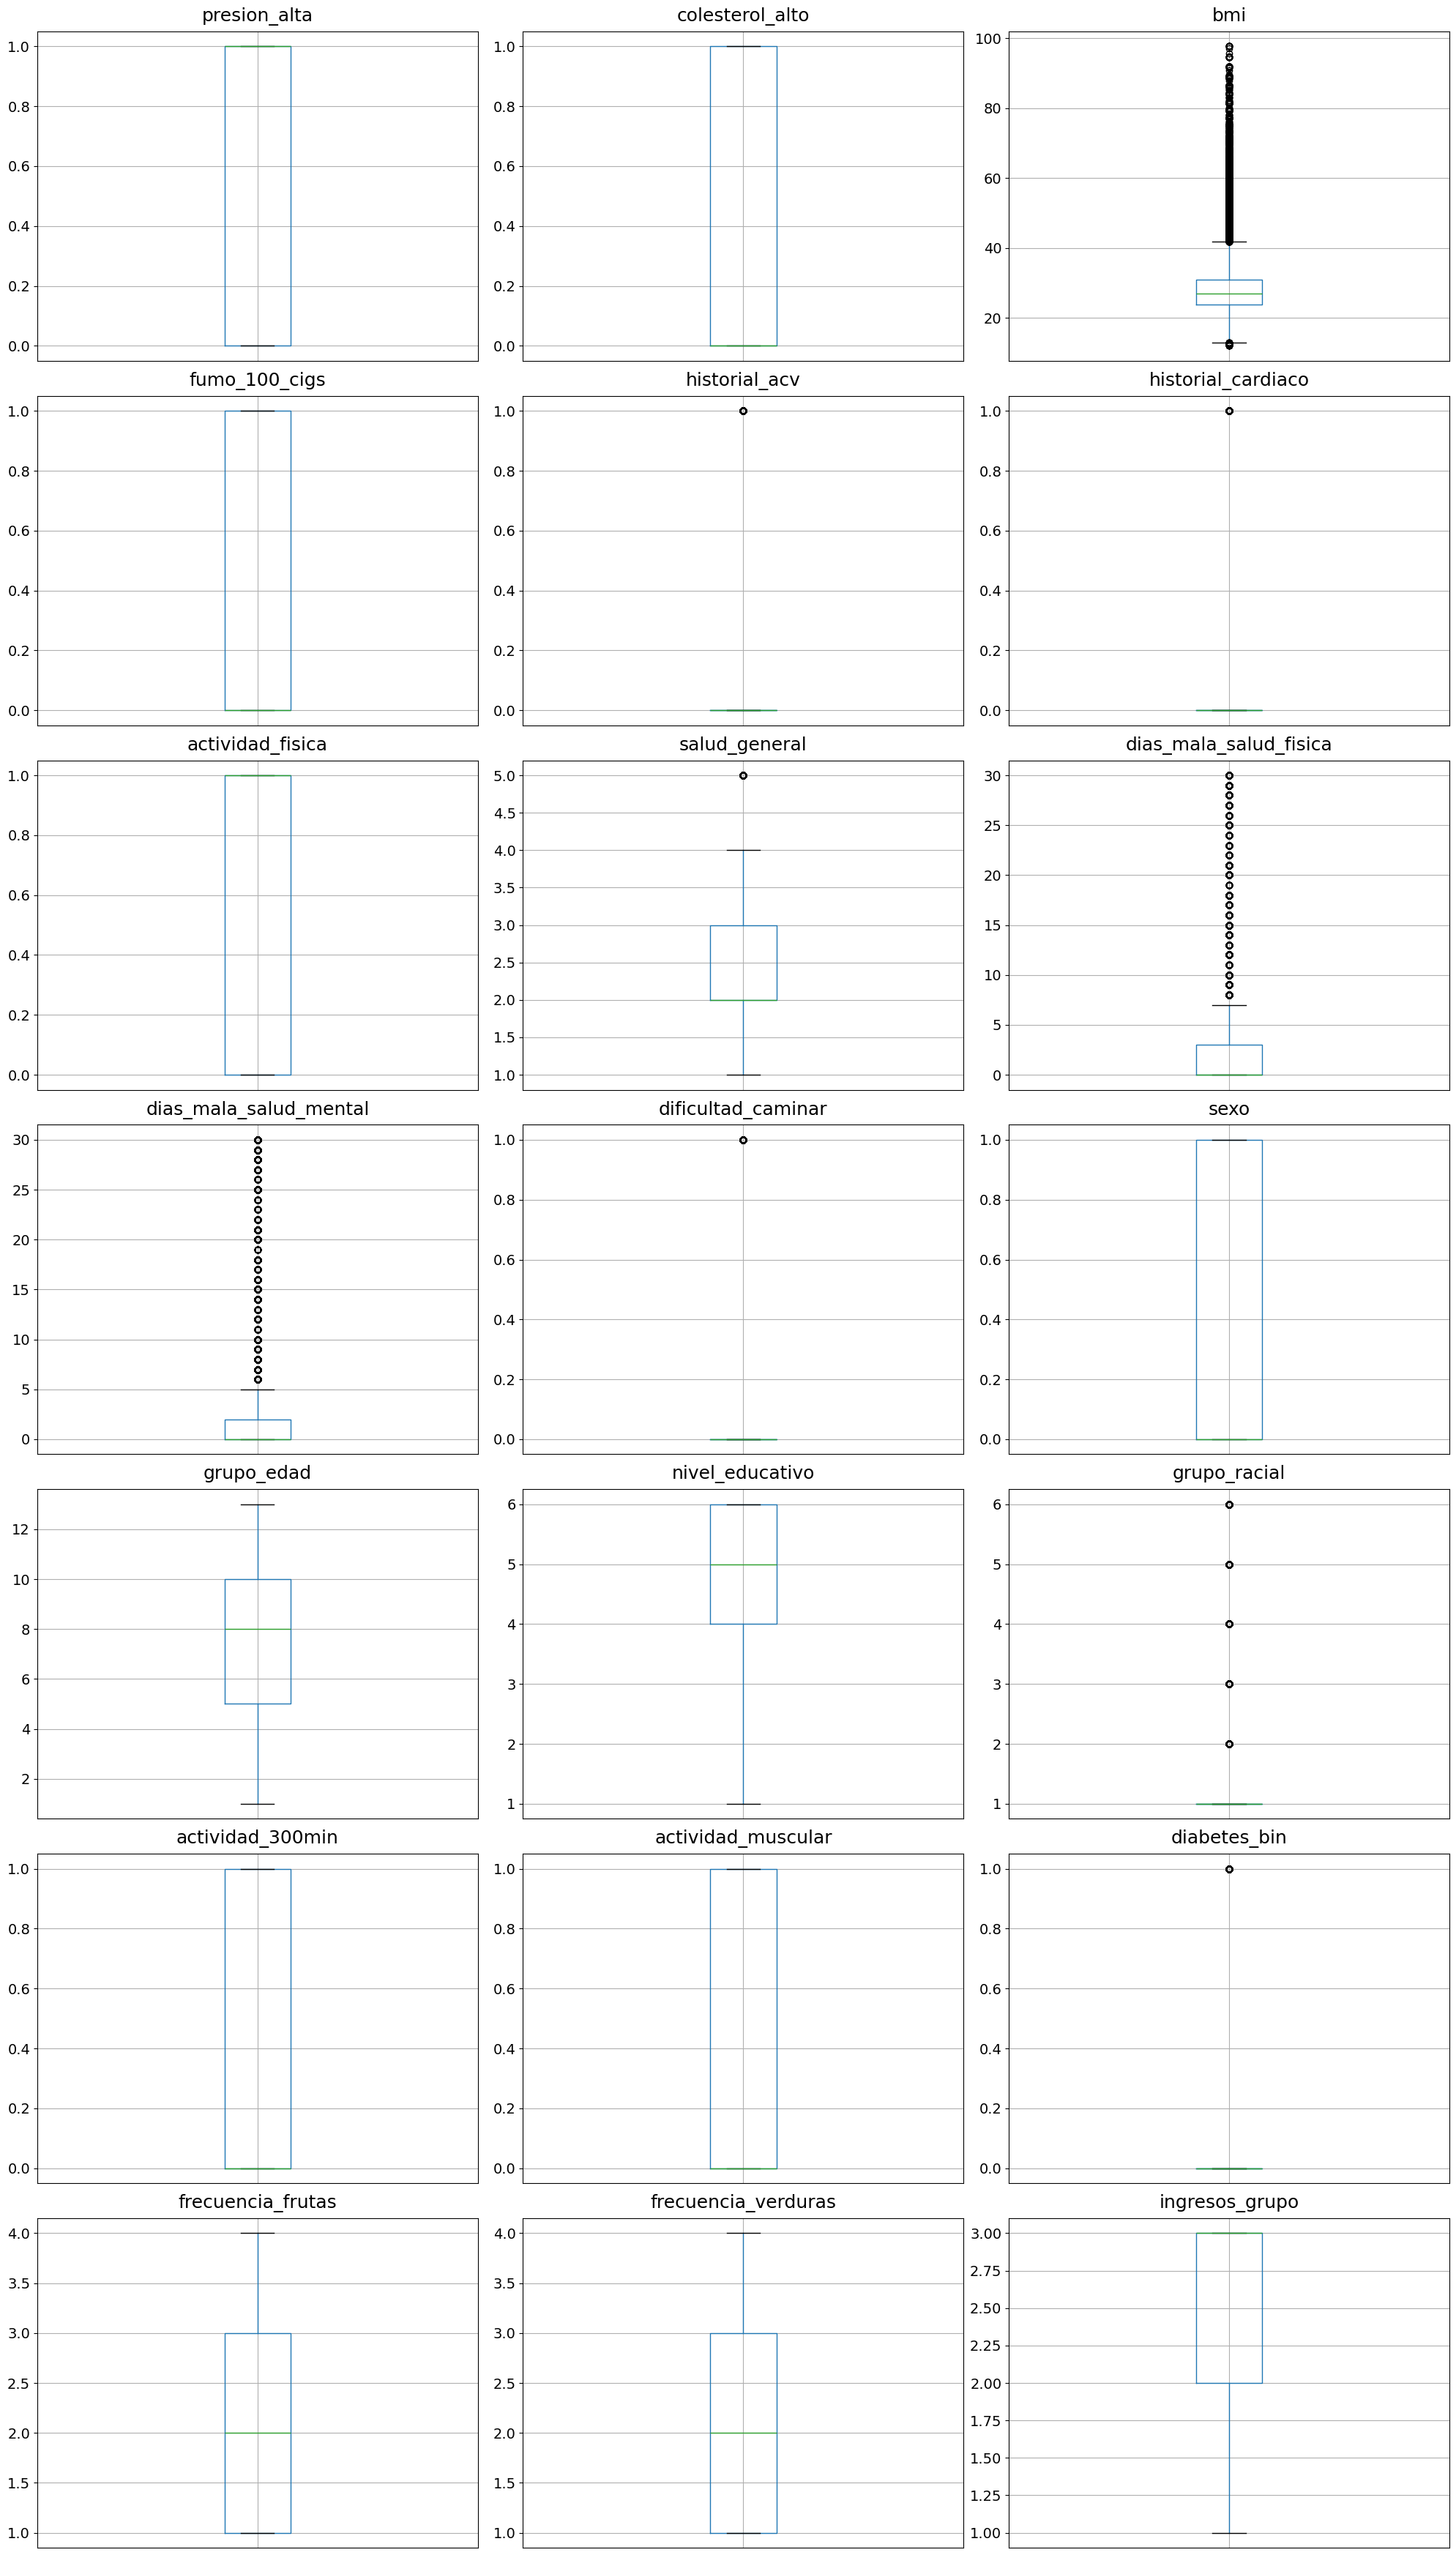

In [46]:
n_cols = 3  
n_rows = int(np.ceil(len(df.columns) / n_cols)) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5)) 

axes = axes.flatten()

for i, col in enumerate(df.columns):
    if i < len(axes): 
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col, fontsize=14, pad=10) 
        axes[i].set_xlabel('') 
        axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
        axes[i].set_title(col, fontsize=18, pad=10) 
        axes[i].tick_params(axis='y', labelsize=14)
        
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.4, wspace=0.3) 
plt.tight_layout()

plt.show()

In [47]:
# Función para calcular el porcentaje de outliers para cada variable
def calcular_porcentaje_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    # Definición de límites para considerar un valor como outlier
    outliers = col[(col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)]

    porcentaje = len(outliers) / len(col) * 100
    return porcentaje

# Ejecución de la función a todas las columnas y almacenar los resultados
porcentajes_outliers = {}
for columna in df.columns:
    porcentajes_outliers[columna] = calcular_porcentaje_outliers(df[columna])

# Impresión de los resultados
print("Porcentaje de outliers por columna: ")
for columna, porcentaje in porcentajes_outliers.items():
    print(f"La columna '{columna}' tiene un {porcentaje:.2f}% de outliers.")

Porcentaje de outliers por columna: 
La columna 'presion_alta' tiene un 0.00% de outliers.
La columna 'colesterol_alto' tiene un 0.00% de outliers.
La columna 'bmi' tiene un 3.36% de outliers.
La columna 'fumo_100_cigs' tiene un 0.00% de outliers.
La columna 'historial_acv' tiene un 4.14% de outliers.
La columna 'historial_cardiaco' tiene un 5.97% de outliers.
La columna 'actividad_fisica' tiene un 0.00% de outliers.
La columna 'salud_general' tiene un 5.23% de outliers.
La columna 'dias_mala_salud_fisica' tiene un 16.16% de outliers.
La columna 'dias_mala_salud_mental' tiene un 14.95% de outliers.
La columna 'dificultad_caminar' tiene un 17.38% de outliers.
La columna 'sexo' tiene un 0.00% de outliers.
La columna 'grupo_edad' tiene un 0.00% de outliers.
La columna 'nivel_educativo' tiene un 0.00% de outliers.
La columna 'grupo_racial' tiene un 22.43% de outliers.
La columna 'actividad_300_min ' tiene un 0.00% de outliers.
La columna 'actividad_muscular' tiene un 0.00% de outliers.
La 

### 2.3. Analisis de variable objetivo


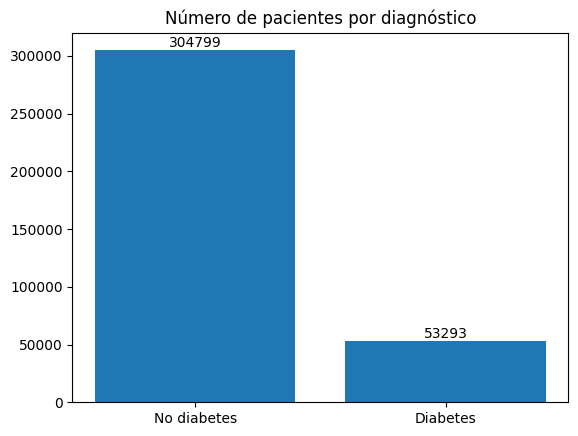

In [48]:
#Imprimiendo el numero de instancias pertenecientes a cada clase de la variable objetivo en un grafico de barras
# Uso de value_counts() para contar los valores de cada clase
conteoclases = df["diabetes_bin"].value_counts()
# Creación de un diccionario para mapear los valores numéricos a los diagnósticos
mapping = {0: 'No diabetes', 1: 'Diabetes'}
#Uso de pltbar() para ingresar indices(etiquetas de clase) y valores(conteo) de conteoclases
plt.bar(conteoclases.index , conteoclases.values)
#Posicionamiento de las etiquetas ligeramente por encima de las barras y con un pequeño offset hacia la izquierda
for i in range(len(conteoclases.index)):
    plt.text(conteoclases.index[i], conteoclases.values[i] + 50, conteoclases.values[i], ha='center', va='bottom', fontsize=10)
#Personalización del gráfico
plt.title("Número de pacientes por diagnóstico")
plt.xticks(conteoclases.index)
# Cambio de las etiquetas del eje x por las letras correspondientes
plt.xticks(conteoclases.index, conteoclases.index.map(mapping))
plt.show()

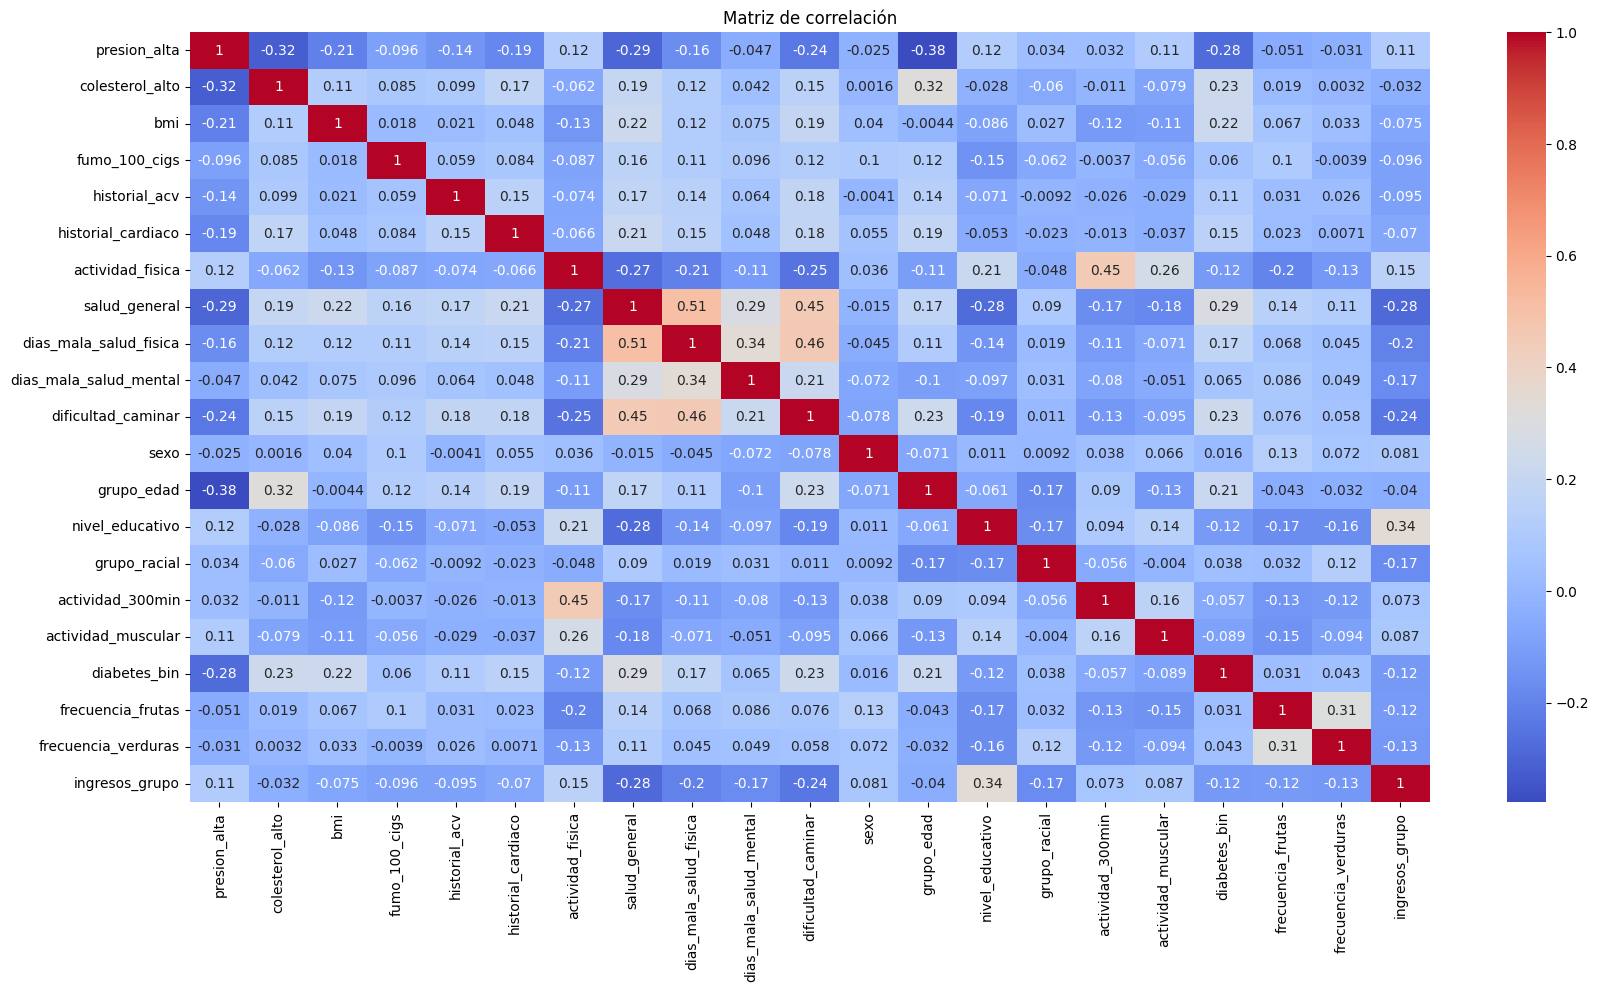

In [49]:
#Matriz de correlación de variables
df = df.select_dtypes(include=[np.number])
correlation_matrix = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

## 3. Preprocesamiento de datos

In [50]:
# Consolidación de la variable objetivo para trabajar con 2 clases: no diabetes (0) y prediabetes y diabetes (1)
df['diabetes_bin'] = df['diabetes_bin'].replace(2, 1)
print("\nDespués de reemplazar 2 con 1 en 'diabetes_bin':")
print(df['diabetes_bin'].value_counts())


Después de reemplazar 2 con 1 en 'diabetes_bin':
diabetes_bin
0    304799
1     53293
Name: count, dtype: int64


In [51]:
# División de columnas en variables de entrada (X) y salida (Y)
X = df.drop(['diabetes_bin'],axis=1)
Y = df['diabetes_bin']
# Normalización de variables de entrada
Xesc = MinMaxScaler().fit_transform(X)

# Asignación de datos a grupos
x_tr, x_te, y_tr, y_te = train_test_split(Xesc, Y, test_size=0.2, random_state=42)

## 4. Primera Iteración: Selección de Algoritmos

## 4.1. Entrenamiento de modelos

In [52]:
# Modelos Básicos

# Creación del modelo 1 - Naive Bayes Bernoulli
modeloNBB = BernoulliNB()
modeloNBB.fit(x_tr, y_tr)
y_pred_NBB = modeloNBB.predict(x_te)

# Creación el modelo 2 - Regresión Logística
modeloRL = LogisticRegression()
modeloRL.fit(x_tr, y_tr)
y_pred_RL = modeloRL.predict(x_te)

# Creación el modelo 3 - Maquinas de cectores de soporte
modeloSVC = SVC(kernel='linear')
modeloSVC.fit(x_tr, y_tr)
y_pred_SVC = modeloSVC.predict(x_te)

# Creación el modelo 4 - Arbol de decisión
modeloDTC = DecisionTreeClassifier()
modeloDTC.fit(x_tr, y_tr)
y_pred_DTC = modeloDTC.predict(x_te)

# Creación el modelo 5 - K vecinos cercanos
modeloKNN = KNeighborsClassifier(n_neighbors=5)
modeloKNN.fit(x_tr, y_tr)
y_pred_KNN = modeloKNN.predict(x_te)

In [53]:
# Modelos de Ensemble Learning

# Creación el modelo 6 - Bosque Aleatorio
modeloRFC = RandomForestClassifier()
modeloRFC.fit(x_tr, y_tr)
y_pred_RFC = modeloRFC.predict(x_te)

# Creación el modelo 7 - XGBoost
modeloXGB = XGBClassifier()
modeloXGB.fit(x_tr, y_tr)
y_pred_XGB = modeloXGB.predict(x_te)

# Creación el modelo 8 - LightGBM
modeloLGB = LGBMClassifier()
modeloLGB.fit(x_tr, y_tr)
y_pred_LGB = modeloLGB.predict(x_te)

[LightGBM] [Info] Number of positive: 42691, number of negative: 243782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 286473, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149023 -> initscore=-1.742286
[LightGBM] [Info] Start training from score -1.742286


c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
# Modelos de Redes Neuronales

# Creación el modelo 9 - Red Neuronal Multicapa
modeloRNM = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(x_tr.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modeloRNM.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history = modeloRNM.fit(x_tr, y_tr, epochs=30, batch_size=32, validation_split=0.2)

loss, accuracy = modeloRNM.evaluate(x_te, y_te)
y_pred_RNM = (modeloRNM.predict(x_te) > 0.5).astype("int32")

Epoch 1/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 6s 754us/step - accuracy: 0.8533 - loss: 0.3477 - val_accuracy: 0.8574 - val_loss: 0.3265
Epoch 2/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 5s 757us/step - accuracy: 0.8563 - loss: 0.3315 - val_accuracy: 0.8578 - val_loss: 0.3251
Epoch 3/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 6s 773us/step - accuracy: 0.8581 - loss: 0.3288 - val_accuracy: 0.8579 - val_loss: 0.3236
Epoch 4/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 6s 767us/step - accuracy: 0.8595 - loss: 0.3253 - val_accuracy: 0.8588 - val_loss: 0.3234
Epoch 5/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 5s 756us/step - accuracy: 0.8574 - loss: 0.3268 - val_accuracy: 0.8591 - val_loss: 0.3234
Epoch 6/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 5s 748us/step - accuracy: 0.8578 - loss: 0.3273 - val_accuracy: 0.8587 - val_loss: 0.3233
Epoch 7/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 5s 755us/step - accuracy: 0.8580 - loss: 0.3277 - val_accuracy: 0.8594 - val_loss: 0.3228
Epoch 8/30
7162/7162 ━━━━━━━━━━━━━━━━━━━━ 5s 752us/step - accuracy: 0.8587 -


Loss: 0.32283124327659607
Accuracy: 0.8596880435943604


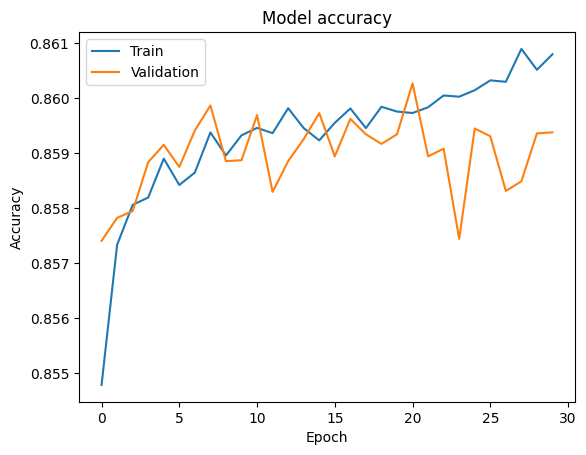

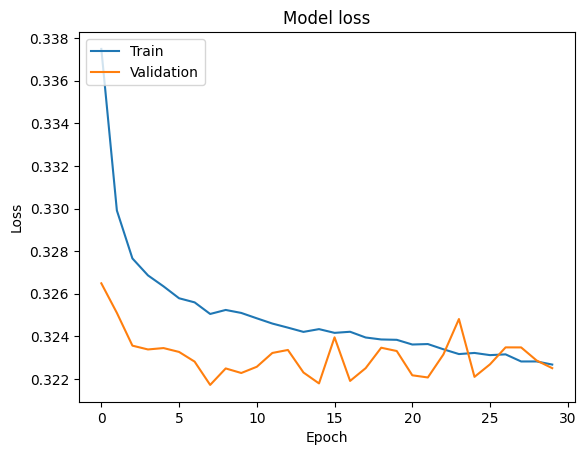

In [55]:
print(f'\nLoss: {loss}')
print(f'Accuracy: {accuracy}')

# Grafica de accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Grafica de función de pérdida
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 4.2. Evaluación de modelos

In [56]:
#Código para mostrar la evaluación de los modelos

accuracy_NBB = accuracy_score(y_te, y_pred_NBB)
precision_NBB = precision_score(y_te, y_pred_NBB, average='weighted', zero_division=0)
recall_NBB = recall_score(y_te, y_pred_NBB, average='weighted')
f1_NBB =  2 * (precision_NBB * recall_NBB) / (precision_NBB + recall_NBB)

print(f" accuracy (Naive Bayes): {accuracy_NBB}")
print(f" precision (Naive Bayes): {precision_NBB}")
print(f" recall (Naive Bayes): {recall_NBB}")
print(f" f1-score (Naive Bayes): {f1_NBB}")

print()

accuracy_RL = accuracy_score(y_te, y_pred_RL)
precision_RL = precision_score(y_te, y_pred_RL, average='weighted', zero_division=0)
recall_RL = recall_score(y_te, y_pred_RL, average='weighted')
f1_RL =  2 * (precision_RL * recall_RL) / (precision_RL + recall_RL)

print(f" accuracy (Regresión Logística): {accuracy_RL}")
print(f" precision (Regresión Logística): {precision_RL}")
print(f" recall (Regresión Logística): {recall_RL}")
print(f" f1-score (Regresión Logística): {f1_RL}")

print()

accuracy_SVC = accuracy_score(y_te, y_pred_SVC)
precision_SVC = precision_score(y_te, y_pred_SVC, average='weighted', zero_division=0)
recall_SVC = recall_score(y_te, y_pred_SVC, average='weighted')
f1_SVC =  2 * (precision_SVC * recall_SVC) / (precision_SVC + recall_SVC)

print(f" accuracy (Support Vector Classifier): {accuracy_SVC}")
print(f" precision (Support Vector Classifier): {precision_SVC}")
print(f" recall (Support Vector Classifier): {recall_SVC}")
print(f" f1-score (Support Vector Classifier): {f1_SVC}")

print()

accuracy_DTC = accuracy_score(y_te, y_pred_DTC)
precision_DTC = precision_score(y_te, y_pred_DTC, average='weighted', zero_division=0)
recall_DTC = recall_score(y_te, y_pred_DTC, average='weighted')
f1_DTC =  2 * (precision_DTC * recall_DTC) / (precision_DTC + recall_DTC)

print(f" accuracy (Decision Tree Classifier): {accuracy_DTC}")
print(f" precision (Decision Tree Classifier): {precision_DTC}")
print(f" recall (Decision Tree Classifier): {recall_DTC}")
print(f" f1-score (Decision Tree Classifier): {f1_DTC}")

print()

accuracy_KNN = accuracy_score(y_te, y_pred_KNN)
precision_KNN = precision_score(y_te, y_pred_KNN, average='weighted', zero_division=0)
recall_KNN = recall_score(y_te, y_pred_KNN, average='weighted')
f1_KNN =  2 * (precision_KNN * recall_KNN) / (precision_KNN + recall_KNN)

print(f" accuracy (Decision Tree Classifier): {accuracy_KNN}")
print(f" precision (Decision Tree Classifier): {precision_KNN}")
print(f" recall (Decision Tree Classifier): {recall_KNN}")
print(f" f1-score (Decision Tree Classifier): {f1_KNN}")

print()

accuracy_RFC = accuracy_score(y_te, y_pred_RFC)
precision_RFC = precision_score(y_te, y_pred_RFC, average='weighted', zero_division=0)
recall_RFC = recall_score(y_te, y_pred_RFC, average='weighted')
f1_RFC =  2 * (precision_RFC * recall_RFC) / (precision_RFC + recall_RFC)

print(f" accuracy (Random Forest): {accuracy_RFC}")
print(f" precision (Random Forest): {precision_RFC}")
print(f" recall (Random Forest): {recall_RFC}")
print(f" f1-score (Random Forest): {f1_RFC}")

print()

accuracy_XGB = accuracy_score(y_te, y_pred_XGB)
precision_XGB = precision_score(y_te, y_pred_XGB, average='weighted', zero_division=0)
recall_XGB = recall_score(y_te, y_pred_XGB, average='weighted')
f1_XGB =  2 * (precision_XGB * recall_XGB) / (precision_XGB + recall_XGB)

print(f" accuracy (Random Forest): {accuracy_XGB}")
print(f" precision (Random Forest): {precision_XGB}")
print(f" recall (Random Forest): {recall_XGB}")
print(f" f1-score (Random Forest): {f1_XGB}")

print()

accuracy_LGB = accuracy_score(y_te, y_pred_LGB)
precision_LGB = precision_score(y_te, y_pred_LGB, average='weighted', zero_division=0)
recall_LGB = recall_score(y_te, y_pred_LGB, average='weighted')
f1_LGB =  2 * (precision_LGB * recall_LGB) / (precision_LGB + recall_LGB)

print(f" accuracy (Red Neuronal Multicapa): {accuracy_LGB}")
print(f" precision (Red Neuronal Multicapa): {precision_LGB}")
print(f" recall (Red Neuronal Multicapa): {recall_LGB}")
print(f" f1-score (Red Neuronal Multicapa): {f1_LGB}")

print()

accuracy_RNM = accuracy_score(y_te, y_pred_RNM)
precision_RNM = precision_score(y_te, y_pred_RNM, average='weighted', zero_division=0)
recall_RNM = recall_score(y_te, y_pred_RNM, average='weighted')
f1_RNM =  2 * (precision_RNM * recall_RNM) / (precision_RNM + recall_RNM)

print(f" accuracy (Red Neuronal Multicapa con Función de Activación): {accuracy_RNM}")
print(f" precision (Red Neuronal Multicapa con Función de Activación): {precision_RNM}")
print(f" recall (Red Neuronal Multicapa con Función de Activación): {recall_RNM}")
print(f" f1-score (Red Neuronal Multicapa con Función de Activación): {f1_RNM}")

 accuracy (Naive Bayes): 0.8198662366131892
 precision (Naive Bayes): 0.8207007993209399
 recall (Naive Bayes): 0.8198662366131892
 f1-score (Naive Bayes): 0.8202833056944484

 accuracy (Regresión Logística): 0.8563090799927393
 precision (Regresión Logística): 0.8243145448727501
 recall (Regresión Logística): 0.8563090799927393
 f1-score (Regresión Logística): 0.8400072676606736

 accuracy (Support Vector Classifier): 0.851966656892724
 precision (Support Vector Classifier): 0.7258471844569645
 recall (Support Vector Classifier): 0.851966656892724
 f1-score (Support Vector Classifier): 0.7838663636361672

 accuracy (Decision Tree Classifier): 0.7882405506918555
 precision (Decision Tree Classifier): 0.7973811212124466
 recall (Decision Tree Classifier): 0.7882405506918555
 f1-score (Decision Tree Classifier): 0.7927844898095238

 accuracy (Decision Tree Classifier): 0.8375151845180748
 precision (Decision Tree Classifier): 0.8038942549995598
 recall (Decision Tree Classifier): 0.83751

In [57]:
# Construccion de tabla de resultados
resultadosPrimIt = {'Modelo': ['Bayes','Regresion Logistica', 'SVM', 'Decision Tree','KNN', 'Random Forest', 'XGBoost','LightGBM', 'RNM'],
        'Accuracy': [accuracy_NBB, accuracy_RL, accuracy_SVC, accuracy_DTC, accuracy_KNN, accuracy_RFC, accuracy_XGB, accuracy_LGB, accuracy_RNM],
        'Precision': [precision_NBB, precision_RL, precision_SVC, precision_DTC, precision_KNN, precision_RFC, precision_XGB, precision_LGB, precision_RNM],
        'Recall': [recall_NBB, recall_RL, recall_SVC, recall_DTC, recall_KNN, recall_RFC, recall_XGB, recall_LGB, recall_RNM],
        'F1-Score': [f1_NBB, f1_RL, f1_SVC, f1_DTC, f1_KNN, f1_RFC, f1_XGB, f1_LGB, f1_RNM]}

df_res1 = pd.DataFrame(resultadosPrimIt)
df_res1.head(10)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Bayes,0.819866,0.820701,0.819866,0.820283
1,Regresion Logistica,0.856309,0.824315,0.856309,0.840007
2,SVM,0.851967,0.725847,0.851967,0.783866
3,Decision Tree,0.788241,0.797381,0.788241,0.792784
4,KNN,0.837515,0.803894,0.837515,0.820360
5,Random Forest,0.855164,0.823551,0.855164,0.839060
6,XGBoost,0.859171,0.830857,0.859171,0.844777
7,LightGBM,0.860442,0.832421,0.860442,0.846199
8,RNM,0.859688,0.830081,0.859688,0.844625


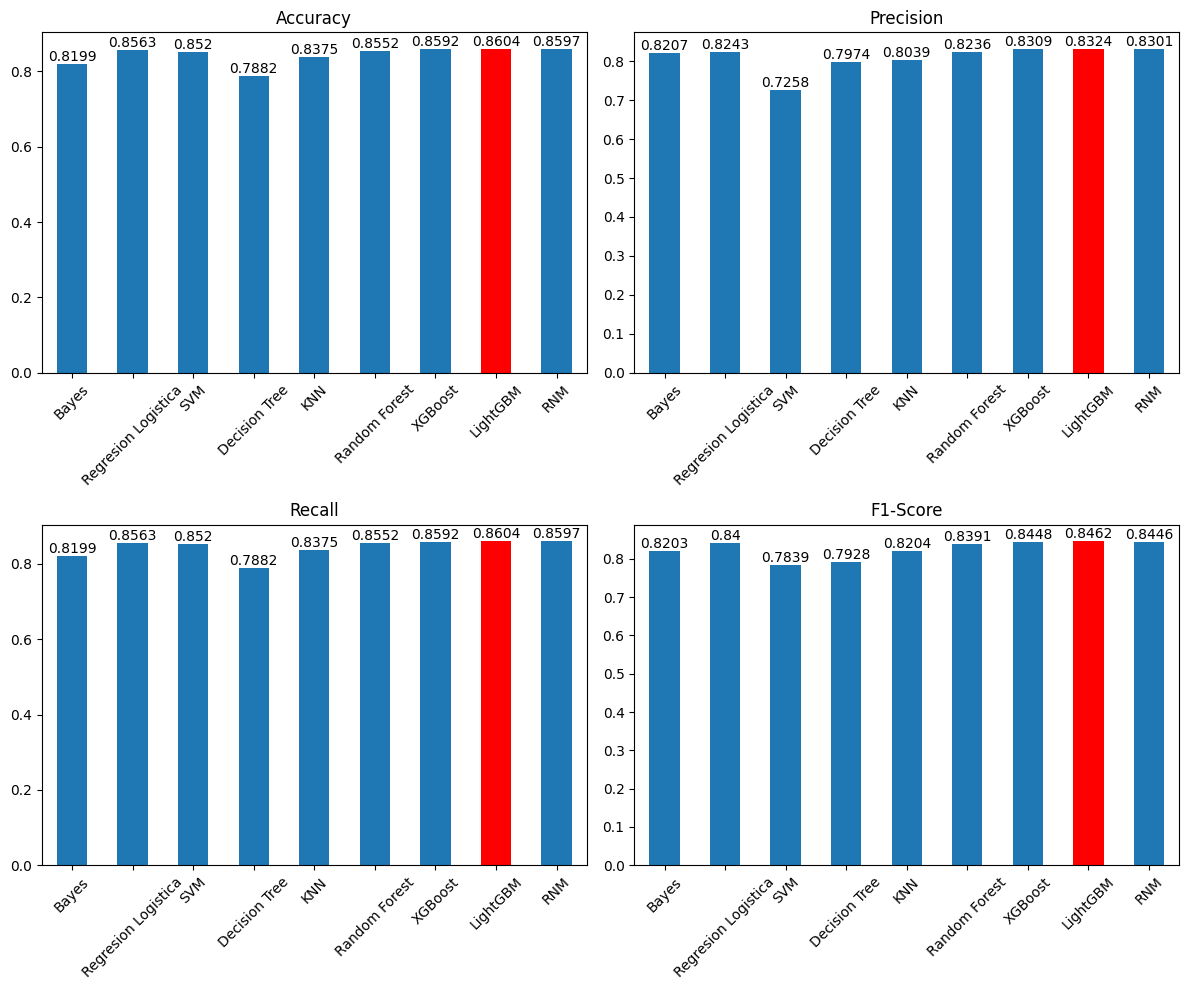

In [58]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

metrics = {'Accuracy': axes[0, 0],
           'Precision': axes[0, 1],
           'Recall': axes[1, 0],
           'F1-Score': axes[1, 1]}

for metric, ax in metrics.items():
    df_res1.plot(x='Modelo', y=metric, kind='bar', ax=ax, title=metric, legend=False)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

    max_value = df_res1[metric].max()

    for p in ax.patches:
        height = round(p.get_height(), 4)
        ax.annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)
        if height == round(max_value, 4):
            p.set_facecolor('red') # Pinta de rojo la barra del valor máximo

plt.tight_layout()
plt.show()

# 5. Segunda Iteración: Optimización automatizada de modelos

## 5.1. Entrenamiento de modelos

In [59]:
def objective_RL(trial):
    """La función objetivo a optimizar para Optuna será F1-Score."""

    # Definición de hiperparámetros a optimizar
    penalty_RL = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet", "none"])
    C_RL = trial.suggest_float("C", 1e-4, 1e4, log=True)
    l1_ratio_RL = None
    if penalty_RL == "elasticnet":
        l1_ratio_RL = trial.suggest_float("l1_ratio", 0, 1)

    # Definición de algoritmo solver
    all_solvers_RL = ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
    solver_RL = trial.suggest_categorical("solver", all_solvers_RL)

    # Revisión de compatibilidad entre solver e hiperparámetro penalty
    if penalty_RL == "l1" and solver_RL not in ["liblinear", "saga"]:
        raise optuna.exceptions.TrialPruned()
    elif penalty_RL == "elasticnet" and solver_RL != "saga":
        raise optuna.exceptions.TrialPruned()
    elif penalty_RL == "none" and solver_RL not in ["newton-cg", "lbfgs", "sag", "saga"]:
        raise optuna.exceptions.TrialPruned()
    elif penalty_RL == "l2" and solver_RL not in ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]:
        raise optuna.exceptions.TrialPruned()

    # Manejo del caso "none"
    final_penalty_RL = penalty_RL if penalty_RL != "none" else None

    # Creación y entrenamiento del modelo de regresión logística
    model_params_RL = {'C': C_RL, 'solver': solver_RL, 'random_state': 42, 'max_iter': 1000}
    if final_penalty_RL is not None:
        model_params_RL['penalty'] = final_penalty_RL
    if l1_ratio_RL is not None:
        model_params_RL['l1_ratio'] = l1_ratio_RL

    model_RL = LogisticRegression(**model_params_RL)

    try:
        model_RL.fit(x_tr, y_tr)
    except ValueError as e:
        if "LogisticRegression supports only" in str(e) or "Specify `l1_ratio`" in str(e):
            raise optuna.exceptions.TrialPruned()
        else:
            raise e

    # Evaluación del modelo usando F1-score
    y_pred_RL = model_RL.predict(x_te)
    f1_RL = f1_score(y_te, y_pred_RL, average='weighted', zero_division=0)
    return f1_RL

# Creación del objeto de estudio y optimización de la función objetivo (F1-Score) para RL
study_RL = optuna.create_study(direction="maximize", study_name="LogisticRegressionOptimization")
study_RL.optimize(objective_RL, n_trials=20)

# Impresión de los mejores hiperparámetros para RL
print("\nMejores hiperparámetros (Regresión Logística): ", study_RL.best_params)

# Entrenamiento del modelo final de RL con los mejores hiperparámetros
best_params_RL = study_RL.best_params
final_penalty_RL = best_params_RL.get('penalty')
final_l1_ratio_RL = best_params_RL.get('l1_ratio')

final_model_params_RL = {'C': best_params_RL['C'], 'solver': best_params_RL['solver'], 'random_state': 42, 'max_iter': 1000}
if final_penalty_RL is not None and final_penalty_RL != 'none':
    final_model_params_RL['penalty'] = final_penalty_RL
elif final_penalty_RL == 'elasticnet':
    final_model_params_RL['l1_ratio'] = final_l1_ratio_RL

best_model_RL = LogisticRegression(**final_model_params_RL)

try:
    best_model_RL.fit(x_tr, y_tr)
    # Evaluación del mejor modelo de RL
    y_pred_RL_tuned = best_model_RL.predict(x_te)

    accuracy_RL_tuned = accuracy_score(y_te, y_pred_RL_tuned)
    precision_RL_tuned = precision_score(y_te, y_pred_RL_tuned, average='weighted', zero_division=0)
    recall_RL_tuned = recall_score(y_te, y_pred_RL_tuned, average='weighted')
    f1_RL_tuned = f1_score(y_te, y_pred_RL_tuned, average='weighted', zero_division=0)

    print("\nMétricas Optimizadas de Regresión Logística (basado en F1-score):")
    print(f" accuracy: {accuracy_RL_tuned}")
    print(f" precision: {precision_RL_tuned}")
    print(f" recall: {recall_RL_tuned}")
    print(f" f1-score: {f1_RL_tuned}")

except ValueError as e:
    print(f"No se pudo entrenar el modelo final (Regresión Logística) con los mejores parámetros debido a: {e}")
    print(f"Mejores parámetros encontrados (Regresión Logística): {best_params_RL}")

[I 2025-06-29 22:43:08,608] A new study created in memory with name: LogisticRegressionOptimization
[I 2025-06-29 22:43:08,609] Trial 0 pruned. 
[I 2025-06-29 22:43:08,610] Trial 1 pruned. 
[I 2025-06-29 22:43:10,191] Trial 2 finished with value: 0.8253182075143407 and parameters: {'penalty': 'l2', 'C': 0.28577249390588116, 'solver': 'sag'}. Best is trial 2 with value: 0.8253182075143407.
[I 2025-06-29 22:43:10,192] Trial 3 pruned. 
[I 2025-06-29 22:43:11,654] Trial 4 finished with value: 0.8254900288437319 and parameters: {'penalty': 'l1', 'C': 87.10766994490432, 'solver': 'saga'}. Best is trial 4 with value: 0.8254900288437319.
[I 2025-06-29 22:43:11,654] Trial 5 pruned. 
[I 2025-06-29 22:43:11,655] Trial 6 pruned. 
[I 2025-06-29 22:43:11,940] Trial 7 finished with value: 0.8253868549650171 and parameters: {'penalty': 'l2', 'C': 75.38940894058324, 'solver': 'lbfgs'}. Best is trial 4 with value: 0.8254900288437319.
[I 2025-06-29 22:43:11,941] Trial 8 pruned. 
[I 2025-06-29 22:43:11,94


Mejores hiperparámetros (Regresión Logística):  {'penalty': 'l1', 'C': 87.10766994490432, 'solver': 'saga'}

Métricas Optimizadas de Regresión Logística (basado en F1-score):
 accuracy: 0.8563090799927393
 precision: 0.8243744115334
 recall: 0.8563090799927393
 f1-score: 0.8254900288437319


In [60]:
def objective_XGB(trial):
    """La función objetivo a optimizar para Optuna será F1-Score usando XGBoost."""

    # Definición de hiperparámetros a optimizar para XGBoost
    n_estimators_XGB = trial.suggest_int("n_estimators", 100, 1000, step=100)
    learning_rate_XGB = trial.suggest_float("learning_rate", 0.001, 0.1, log=True)
    max_depth_XGB = trial.suggest_int("max_depth", 3, 10)
    min_child_weight_XGB = trial.suggest_int("min_child_weight", 1, 10)
    subsample_XGB = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree_XGB = trial.suggest_float("colsample_bytree", 0.5, 1.0)

    # Creación y entrenamiento del modelo XGBoost
    model_XGB = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=n_estimators_XGB,
        learning_rate=learning_rate_XGB,
        max_depth=max_depth_XGB,
        min_child_weight=min_child_weight_XGB,
        subsample=subsample_XGB,
        colsample_bytree=colsample_bytree_XGB,
        random_state=42,
        n_jobs=-1 # Usar todos los núcleos
    )

    model_XGB.fit(x_tr, y_tr)

    # Evaluación del modelo usando F1-score (ponderado por el desbalance)
    y_pred_XGB = model_XGB.predict(x_te)
    f1_XGB = f1_score(y_te, y_pred_XGB, average='weighted', zero_division=0)
    return f1_XGB

# Creación del objeto de estudio y optimización de la función objetivo (F1-Score) para XGB
study_XGB = optuna.create_study(direction="maximize", study_name="XGBoostOptimization")
study_XGB.optimize(objective_XGB, n_trials=20)

# Impresión de los mejores hiperparámetros para XGB
print("\nMejores hiperparámetros (XGBoost): ", study_XGB.best_params)

# Entrenamiento del modelo final de XGBoost con los mejores hiperparámetros
best_params_XGB = study_XGB.best_params
best_model_XGB = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    **best_params_XGB
)

best_model_XGB.fit(x_tr, y_tr)

# Evaluación del mejor modelo de XGBoost
y_pred_XGB_tuned = best_model_XGB.predict(x_te)
f1_XGB_tuned = f1_score(y_te, y_pred_XGB_tuned, average='weighted', zero_division=0)
accuracy_XGB_tuned = accuracy_score(y_te, y_pred_XGB_tuned)
precision_XGB_tuned = precision_score(y_te, y_pred_XGB_tuned, average='weighted', zero_division=0)
recall_XGB_tuned = recall_score(y_te, y_pred_XGB_tuned, average='weighted')

print("\nMétricas Optimizadas de XGBoost (basado en F1-score):")
print(f" F1-score: {f1_XGB_tuned}")
print(f" Accuracy: {accuracy_XGB_tuned}")
print(f" Precision: {precision_XGB_tuned}")
print(f" Recall: {recall_XGB_tuned}")

[I 2025-06-29 22:43:24,943] A new study created in memory with name: XGBoostOptimization
[I 2025-06-29 22:43:28,937] Trial 0 finished with value: 0.829518290526677 and parameters: {'n_estimators': 900, 'learning_rate': 0.07104731775081752, 'max_depth': 9, 'min_child_weight': 3, 'subsample': 0.6775272106693727, 'colsample_bytree': 0.6465100720764974}. Best is trial 0 with value: 0.829518290526677.
[I 2025-06-29 22:43:29,371] Trial 1 finished with value: 0.7838663636361672 and parameters: {'n_estimators': 100, 'learning_rate': 0.0017870334632525985, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.676163036333861, 'colsample_bytree': 0.7614009768047421}. Best is trial 0 with value: 0.829518290526677.
[I 2025-06-29 22:43:30,064] Trial 2 finished with value: 0.7838663636361672 and parameters: {'n_estimators': 200, 'learning_rate': 0.0018783314945502309, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.6735471061091305, 'colsample_bytree': 0.5360614148405128}. Best is trial 0 with


Mejores hiperparámetros (XGBoost):  {'n_estimators': 300, 'learning_rate': 0.08660792425488399, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.7144706002582305, 'colsample_bytree': 0.9916029691029147}

Métricas Optimizadas de XGBoost (basado en F1-score):
 F1-score: 0.8326749355042776
 Accuracy: 0.8610005724737849
 Precision: 0.8335260856536609
 Recall: 0.8610005724737849


In [61]:
def objective_LGB(trial):
    """La función objetivo a optimizar para Optuna será F1-Score usando LightGBM."""

    # Definición de hiperparámetros a optimizar para LightGBM
    n_estimators_LGB = trial.suggest_int("n_estimators", 100, 1000, step=100)
    learning_rate_LGB = trial.suggest_float("learning_rate", 0.001, 0.1, log=True)
    num_leaves_LGB = trial.suggest_int("num_leaves", 31, 150)
    min_child_samples_LGB = trial.suggest_int("min_child_samples", 20, 100)
    subsample_LGB = trial.suggest_float("subsample", 0.7, 1.0)
    colsample_bytree_LGB = trial.suggest_float("colsample_bytree", 0.7, 1.0)

    # Creación y entrenamiento del modelo LightGBM
    model_LGB = LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        n_estimators=n_estimators_LGB,
        learning_rate=learning_rate_LGB,
        num_leaves=num_leaves_LGB,
        min_child_samples=min_child_samples_LGB,
        subsample=subsample_LGB,
        colsample_bytree=colsample_bytree_LGB,
        random_state=42,
        n_jobs=-1
    )

    model_LGB.fit(x_tr, y_tr)

    # Evaluación del modelo usando F1-score (ponderado por el desbalance)
    y_pred_LGB = model_LGB.predict(x_te)
    f1_LGB = f1_score(y_te, y_pred_LGB, average='weighted', zero_division=0)
    return f1_LGB

# Creación del objeto de estudio y optimización de la función objetivo (F1-Score) para LGB
study_LGB = optuna.create_study(direction="maximize", study_name="LightGBMOptimization")
study_LGB.optimize(objective_LGB, n_trials=20)

# Impresión de los mejores hiperparámetros para LGB
print("\nMejores hiperparámetros (LightGBM): ", study_LGB.best_params)

# Entrenamiento del modelo final de LightGBM con los mejores hiperparámetros
best_params_LGB = study_LGB.best_params
best_model_LGB = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    n_jobs=-1,
    **best_params_LGB
)

best_model_LGB.fit(x_tr, y_tr)

# Evaluación del mejor modelo de LightGBM
y_pred_LGB_tuned = best_model_LGB.predict(x_te)
f1_LGB_tuned = f1_score(y_te, y_pred_LGB_tuned, average='weighted', zero_division=0)
accuracy_LGB_tuned = accuracy_score(y_te, y_pred_LGB_tuned)
precision_LGB_tuned = precision_score(y_te, y_pred_LGB_tuned, average='weighted', zero_division=0)
recall_LGB_tuned = recall_score(y_te, y_pred_LGB_tuned, average='weighted')

print("\nMétricas Optimizadas de LightGBM (basado en F1-score):")
print(f" F1-score: {f1_LGB_tuned}")
print(f" Accuracy: {accuracy_LGB_tuned}")
print(f" Precision: {precision_LGB_tuned}")
print(f" Recall: {recall_LGB_tuned}")

[I 2025-06-29 22:44:05,607] A new study created in memory with name: LightGBMOptimization


[LightGBM] [Info] Number of positive: 42691, number of negative: 243782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 286473, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149023 -> initscore=-1.742286
[LightGBM] [Info] Start training from score -1.742286


c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-29 22:44:08,263] Trial 0 finished with value: 0.8321129211543122 and parameters: {'n_estimators': 600, 'learning_rate': 0.015364202673657113, 'num_leaves': 110, 'min_child_samples': 90, 'subsample': 0.8204042838027271, 'colsample_bytree': 0.8388069784418679}. Best is trial 0 with value: 0.8321129211543122.


[LightGBM] [Info] Number of positive: 42691, number of negative: 243782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 286473, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149023 -> initscore=-1.742286
[LightGBM] [Info] Start training from score -1.742286


c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-29 22:44:09,928] Trial 1 finished with value: 0.8321609486784559 and parameters: {'n_estimators': 800, 'learning_rate': 0.058027837277053136, 'num_leaves': 37, 'min_child_samples': 67, 'subsample': 0.767670223666282, 'colsample_bytree': 0.9886631407058514}. Best is trial 1 with value: 0.8321609486784559.


...

c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-29 22:44:35,465] Trial 18 finished with value: 0.8307046141363388 and parameters: {'n_estimators': 100, 'learning_rate': 0.053370201867102014, 'num_leaves': 45, 'min_child_samples': 47, 'subsample': 0.9364358357570585, 'colsample_bytree': 0.7517554658213724}. Best is trial 16 with value: 0.8325534172512624.


[LightGBM] [Info] Number of positive: 42691, number of negative: 243782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 286473, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149023 -> initscore=-1.742286
[LightGBM] [Info] Start training from score -1.742286


c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-29 22:44:36,827] Trial 19 finished with value: 0.8319524971766973 and parameters: {'n_estimators': 600, 'learning_rate': 0.0935386381277735, 'num_leaves': 66, 'min_child_samples': 75, 'subsample': 0.8749961364554063, 'colsample_bytree': 0.8197552061462348}. Best is trial 16 with value: 0.8325534172512624.



Mejores hiperparámetros (LightGBM):  {'n_estimators': 600, 'learning_rate': 0.04192437210502465, 'num_leaves': 48, 'min_child_samples': 73, 'subsample': 0.8872329024456458, 'colsample_bytree': 0.8481921723476543}
[LightGBM] [Info] Number of positive: 42691, number of negative: 243782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 286473, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149023 -> initscore=-1.742286
[LightGBM] [Info] Start training from score -1.742286

Métricas Optimizadas de LightGBM (basado en F1-score):
 F1-score: 0.8325534172512624
 Accuracy: 0.8608888702718552
 Precision: 0.8333283186799754
 Recall: 0.8608888702718552


c:\ProyectosML\202502 - ML\TFM\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [62]:
def objective_RNM(trial):
    """La función objetivo a optimizar para Optuna será F1-Score usando una Red Neuronal."""

    # Definición de hiperparámetros a optimizar para la Red Neuronal (ajustado para 22 inputs)
    n_units_layer1_RNM = trial.suggest_int("n_units_layer1", 64, 256)
    dropout_rate1_RNM = trial.suggest_float("dropout_rate1", 0.0, 0.5)
    n_units_layer2_RNM = trial.suggest_int("n_units_layer2", 32, 128)
    dropout_rate2_RNM = trial.suggest_float("dropout_rate2", 0.0, 0.5)
    optimizer_RNM = trial.suggest_categorical("optimizer", ["adam", "rmsprop"])
    batch_size_RNM = trial.suggest_categorical("batch_size", [32, 64, 128])

    # Creación del modelo de Red Neuronal Multicapa
    modelo_RNM = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(x_tr.shape[1],)),
        tf.keras.layers.Dense(n_units_layer1_RNM, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate1_RNM),
        tf.keras.layers.Dense(n_units_layer2_RNM, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate2_RNM),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    modelo_RNM.compile(optimizer=optimizer_RNM,
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

    # Entrenamiento del modelo
    history_RNM = modelo_RNM.fit(x_tr, y_tr, epochs=10, batch_size=batch_size_RNM,
                                  validation_split=0.2, verbose=0) # verbose=0 para no llenar la salida

    # Evaluación del modelo
    y_pred_RNM_proba = modelo_RNM.predict(x_te, verbose=0)
    y_pred_RNM = (y_pred_RNM_proba > 0.5).astype("int32")
    f1_RNM = f1_score(y_te, y_pred_RNM, average='weighted', zero_division=0)

    # Limpiar la sesión de Keras para evitar problemas de memoria en trials sucesivos
    tf.keras.backend.clear_session()

    return f1_RNM

# Creación del objeto de estudio y optimización de la función objetivo (F1-Score) para RNM
study_RNM = optuna.create_study(direction="maximize", study_name="RedNeuronalOptimization")
study_RNM.optimize(objective_RNM, n_trials=20)

# Impresión de los mejores hiperparámetros para RNM
print("\nMejores hiperparámetros (Red Neuronal): ", study_RNM.best_params)

# Entrenamiento del modelo final de Red Neuronal con los mejores hiperparámetros
best_params_RNM = study_RNM.best_params
best_model_RNM = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(x_tr.shape[1],)),
    tf.keras.layers.Dense(best_params_RNM['n_units_layer1'], activation='relu'),
    tf.keras.layers.Dropout(best_params_RNM['dropout_rate1']),
    tf.keras.layers.Dense(best_params_RNM['n_units_layer2'], activation='relu'),
    tf.keras.layers.Dropout(best_params_RNM['dropout_rate2']),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

best_model_RNM.compile(optimizer=best_params_RNM['optimizer'],
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

best_model_RNM.fit(x_tr, y_tr, epochs=30, batch_size=best_params_RNM['batch_size'],
                    validation_split=0.2, verbose=0)

# Evaluación del mejor modelo de Red Neuronal
y_pred_RNM_proba_tuned = best_model_RNM.predict(x_te, verbose=0)
y_pred_RNM_tuned = (y_pred_RNM_proba_tuned > 0.5).astype("int32")
f1_RNM_tuned = f1_score(y_te, y_pred_RNM_tuned, average='weighted', zero_division=0)
accuracy_RNM_tuned = accuracy_score(y_te, y_pred_RNM_tuned)
precision_RNM_tuned = precision_score(y_te, y_pred_RNM_tuned, average='weighted', zero_division=0)
recall_RNM_tuned = recall_score(y_te, y_pred_RNM_tuned, average='weighted')

print("\nMétricas Optimizadas de Red Neuronal (basado en F1-score):")
print(f" F1-score: {f1_RNM_tuned}")
print(f" Accuracy: {accuracy_RNM_tuned}")
print(f" Precision: {precision_RNM_tuned}")
print(f" Recall: {recall_RNM_tuned}")

[I 2025-06-29 22:44:38,171] A new study created in memory with name: RedNeuronalOptimization


[I 2025-06-29 22:45:34,793] Trial 0 finished with value: 0.8276878320640562 and parameters: {'n_units_layer1': 229, 'dropout_rate1': 0.11425795476535949, 'n_units_layer2': 32, 'dropout_rate2': 0.17792586775817176, 'optimizer': 'adam', 'batch_size': 32}. Best is trial 0 with value: 0.8276878320640562.
[I 2025-06-29 22:46:04,291] Trial 1 finished with value: 0.8204037081035963 and parameters: {'n_units_layer1': 92, 'dropout_rate1': 0.4539887963167978, 'n_units_layer2': 42, 'dropout_rate2': 0.4696415620550324, 'optimizer': 'adam', 'batch_size': 64}. Best is trial 0 with value: 0.8276878320640562.
[I 2025-06-29 22:46:23,089] Trial 2 finished with value: 0.8313949011477555 and parameters: {'n_units_layer1': 232, 'dropout_rate1': 0.11500099001667508, 'n_units_layer2': 50, 'dropout_rate2': 0.2122497250158228, 'optimizer': 'rmsprop', 'batch_size': 128}. Best is trial 2 with value: 0.8313949011477555.
[I 2025-06-29 22:46:55,141] Trial 3 finished with value: 0.82944473665345 and parameters: {'n_


Mejores hiperparámetros (Red Neuronal):  {'n_units_layer1': 118, 'dropout_rate1': 0.08883838885978879, 'n_units_layer2': 70, 'dropout_rate2': 0.2443466314461602, 'optimizer': 'rmsprop', 'batch_size': 128}

Métricas Optimizadas de Red Neuronal (basado en F1-score):
 F1-score: 0.8291025650122976
 Accuracy: 0.8599673271059356
 Precision: 0.8310746562083603
 Recall: 0.8599673271059356


## 5.2. Evaluación de modelos

In [63]:
# Construccion de tabla de resultados
resultadosSegIt = {'Modelo': ['Regresion Logistica', 'XGBoost','LightGBM', 'RNM'],
        'Accuracy': [accuracy_RL_tuned, accuracy_XGB_tuned, accuracy_LGB_tuned, accuracy_RNM_tuned],
        'Precision': [precision_RL_tuned, precision_XGB_tuned, precision_LGB_tuned, precision_RNM_tuned],
        'Recall': [recall_RL_tuned, recall_XGB_tuned, recall_LGB_tuned, recall_RNM_tuned],
        'F1-Score': [f1_RL_tuned, f1_XGB_tuned, f1_LGB_tuned, f1_RNM_tuned]}

df_res2 = pd.DataFrame(resultadosSegIt)
df_res2.head(10)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresion Logistica,0.856309,0.824374,0.856309,0.825490
1,XGBoost,0.861001,0.833526,0.861001,0.832675
2,LightGBM,0.860889,0.833328,0.860889,0.832553
3,RNM,0.859967,0.831075,0.859967,0.829103


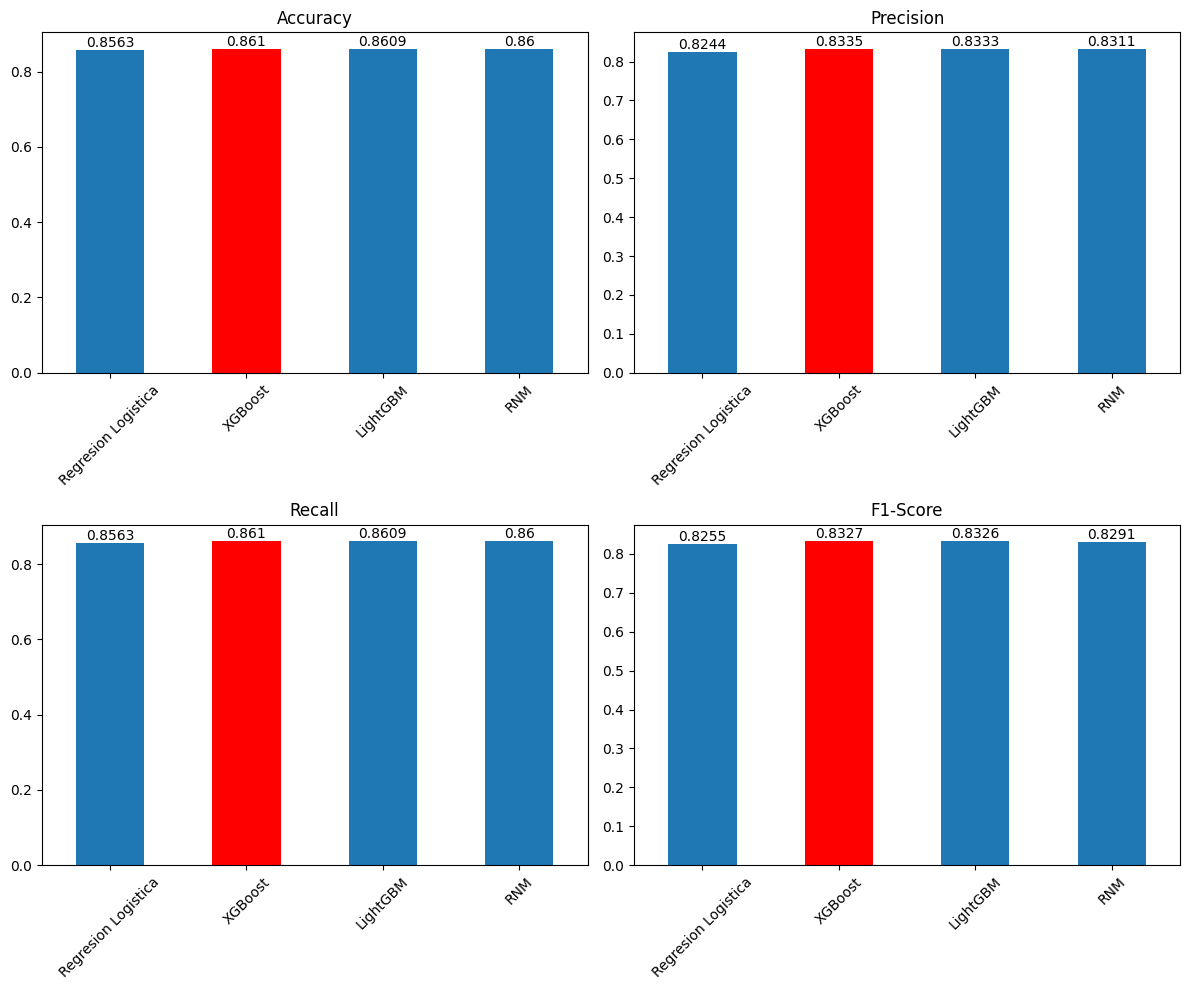

In [64]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

metrics = {'Accuracy': axes[0, 0],
           'Precision': axes[0, 1],
           'Recall': axes[1, 0],
           'F1-Score': axes[1, 1]}

for metric, ax in metrics.items():
    df_res2.plot(x='Modelo', y=metric, kind='bar', ax=ax, title=metric, legend=False)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

    max_value = df_res2[metric].max()

    for p in ax.patches:
        height = round(p.get_height(), 4)
        ax.annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)
        if height == round(max_value, 4):
            p.set_facecolor('red') # Pinta de rojo la barra del valor máximo

plt.tight_layout()
plt.show()